# Trabalho A2 - Modelagem Matemática
Implementação do paradoxo de Braess

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


class BraessSimulation:
    def __init__(
        self,
        total_users=4000,
        max_iter=1000,
        tolerance=1,
        learning_rate=0.20,     # controle de velocidade de adaptação dos usuários durante a simulação
        with_shortcut=False
    ):
        self.total_users = total_users
        self.max_iter = max_iter
        self.tolerance = tolerance
        self.learning_rate = learning_rate
        self.with_shortcut = with_shortcut

        if with_shortcut:
            self.routes = {
                "ABD": total_users,
                "ACD": 0,
                "ABCD": 0
            }
        else:
            self.routes = {
                "ABD": total_users,
                "ACD": 0
            }

        self.history = []

    def compute_edge_flows(self):

        abd = self.routes.get("ABD", 0)
        acd = self.routes.get("ACD", 0)
        abcd = self.routes.get("ABCD", 0)

        flows = {
            "AB": abd + abcd,
            "BD": abd,
            "AC": acd,
            "CD": acd + abcd,
            "BC": abcd
        }

        return flows

    def compute_route_times(self):

        f = self.compute_edge_flows()

        times = {}

        times["ABD"] = f["AB"] / 100 + 45
        times["ACD"] = 45 + f["CD"] / 100

        if self.with_shortcut:
            times["ABCD"] = f["AB"] / 100 + f["CD"] / 100

        return times

    def average_time(self, times):

        total = 0

        for route, users in self.routes.items():
            total += users * times[route]

        return total / self.total_users

    def run(self):

        for iteration in range(self.max_iter):

            times = self.compute_route_times()

            best_route = min(times, key=times.get)
            worst_route = max(times, key=times.get)

            diff = times[worst_route] - times[best_route]

            move = int(
                self.learning_rate *
                (diff / max(times.values())) *
                self.routes[worst_route]
            )

            move = max(move, 0)

            self.history.append({
                "iter": iteration,
                **self.routes,
                **times,
                "avg_time": self.average_time(times)
            })

            if move <= self.tolerance:
                break

            self.routes[worst_route] -= move
            self.routes[best_route] += move

        return {
            "iterations": iteration,
            "routes": self.routes,
            "times": times,
            "avg_time": self.average_time(times),
            "history": pd.DataFrame(self.history)
        }

In [ ]:
# EXECUÇÃO

s_atalho = BraessSimulation(with_shortcut=False)    # simulação sem atalho
result_s_atalho = s_atalho.run()

c_atalho = BraessSimulation(with_shortcut=True)     # simulação com atalho
result_c_atalho = c_atalho.run()

print("=" * 60)
print("SEM ATALHO")
print("=" * 60)
print("Iterações:", result_s_atalho["iterations"])
print("Fluxo final:", result_s_atalho["routes"])
print("Tempos finais:", result_s_atalho["times"])
print("Tempo médio:", round(result_s_atalho["avg_time"], 2))

print()

print("=" * 60)
print("COM ATALHO")
print("=" * 60)
print("Iterações:", result_c_atalho["iterations"])
print("Fluxo final:", result_c_atalho["routes"])
print("Tempos finais:", result_c_atalho["times"])
print("Tempo médio:", round(result_c_atalho["avg_time"], 2))

SEM ATALHO
Iterações: 35
Fluxo final: {'ABD': 2016, 'ACD': 1984}
Tempos finais: {'ABD': 65.16, 'ACD': 64.84}
Tempo médio: 65.0

COM ATALHO
Iterações: 130
Fluxo final: {'ABD': 134, 'ACD': 0, 'ABCD': 3866}
Tempos finais: {'ABD': 85.0, 'ACD': 83.66, 'ABCD': 78.66}
Tempo médio: 78.87


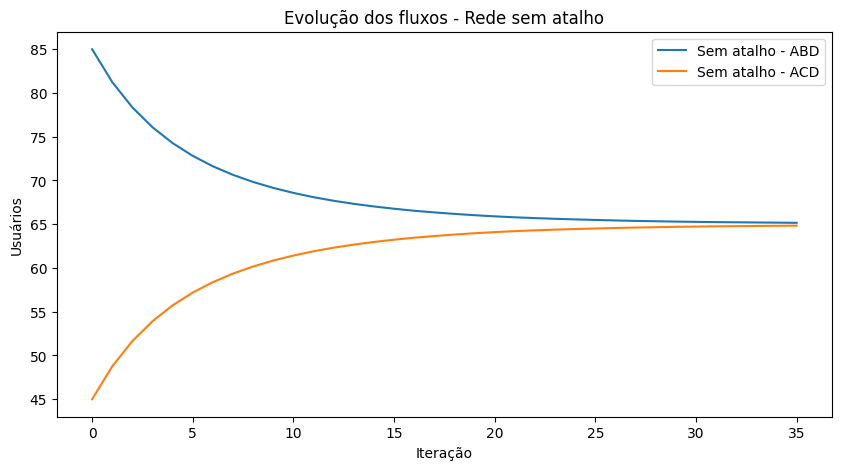

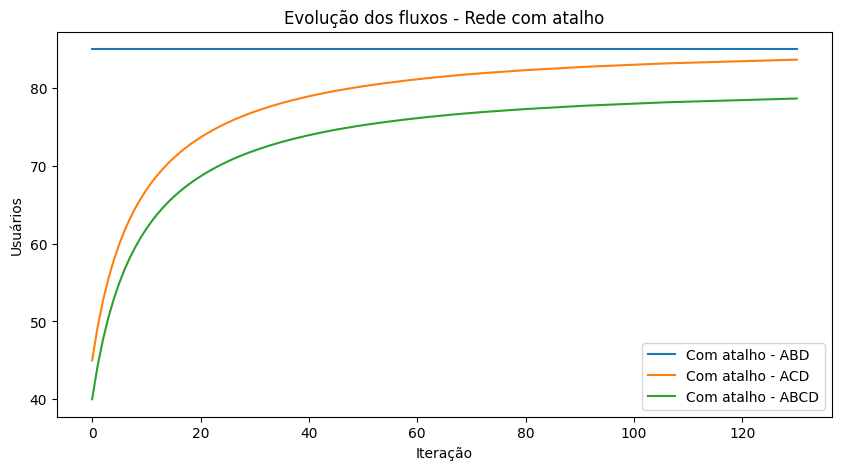

In [ ]:
# GRÁFICOS

plt.figure(figsize=(10, 5))

for col in result_s_atalho["routes"].keys():
    plt.plot(
        result_s_atalho["history"]["iter"],
        result_s_atalho["history"][col],
        label=f"Sem atalho - {col}"
    )

plt.legend()
plt.xlabel("Iteração")
plt.ylabel("Usuários")
plt.title("Evolução dos fluxos - Rede sem atalho")
plt.show()


plt.figure(figsize=(10, 5))

for col in result_c_atalho["routes"].keys():
    plt.plot(
        result_c_atalho["history"]["iter"],
        result_c_atalho["history"][col],
        label=f"Com atalho - {col}"
    )

plt.legend()
plt.xlabel("Iteração")
plt.ylabel("Usuários")
plt.title("Evolução dos fluxos - Rede com atalho")
plt.show()